# Alaska 2024: Peltola overperformance vs. Harris

This notebook is the end-to-end pipeline for v1 of the `ak-electoral-map`
project. It fetches the 2024 general election data from the Alaska Division
of Elections and the precinct shapefile from the AK GIS portal, joins them,
computes Peltola-vs-Harris overperformance per precinct (and per House-District
absentee cohort), and writes the static maps and top-N tables published in the
repo.

Running this notebook top-to-bottom reproduces everything under `outputs/` and
`docs/`. It is safe to re-run — fetch is idempotent.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from ak_electoral_map import clean, fetch, metrics

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = REPO_ROOT / "outputs"
MAPS = OUTPUTS / "maps"
TABLES = OUTPUTS / "tables"
DOCS = REPO_ROOT / "docs"
for d in (MAPS, TABLES, DOCS):
    d.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

Downloads `ENRbyPrecinct.csv`, `ElectionSummaryReport.pdf`, and
`precincts.geojson` into `data/raw/`. Cached on subsequent runs.

In [2]:
manifest = fetch.fetch_all()
pd.DataFrame(manifest).T[["filename", "bytes", "retrieved_at"]]

[fetch] precinct_results: reusing cached ENRbyPrecinct.csv
[fetch] statewide_summary: reusing cached ElectionSummaryReport.pdf
[fetch] precinct_boundaries: reusing cached precincts.geojson


[fetch] wrote data/raw/MANIFEST.json


,filename,bytes,retrieved_at
precinct_results,ENRbyPrecinct.csv,3645454,2026-04-24T14:31:41.931874+00:00
statewide_summary,ElectionSummaryReport.pdf,276645,2026-04-24T14:31:42.553056+00:00
precinct_boundaries,precincts.geojson,26799614,2026-04-24T14:31:48.104745+00:00


## 2. Clean and join

Produces a unified GeoDataFrame with 441 rows: 401 geographic precincts
(election-day ballots) + 40 HD-absentee pseudo-precincts (Absentee + Early
Voting + Question ballots aggregated per House District). HD-absentee rows use
the dissolved HD polygon as their geometry.

In [3]:
raw_gdf = clean.clean()
clean.write_processed(raw_gdf)
gdf = metrics.with_metrics(raw_gdf)
gdf["row_type"].value_counts()

[clean] wrote data/processed/precincts_2024.geojson (29597 KB)
[clean] wrote data/processed/precincts_2024.parquet (16540 KB)


row_type
precinct       401
hd_absentee     40
Name: count, dtype: int64

## 3. Statewide sanity check

Summed precinct + HD-absentee totals should match DoE certified totals within
~400 votes (the HD99 "Fed Overseas" ballots are dropped — they have no home HD).

In [4]:
summary = metrics.statewide_summary(gdf)
pd.Series(summary).to_frame("value")

,value
harris_votes,139690.000000
trump_votes,184407.000000
peltola_r1_votes,152534.000000
begich_r1_votes,159500.000000
pres_total,337776.000000
house_r1_total,328423.000000
harris_pct,41.355810
trump_pct,54.594465
peltola_pct_r1,46.444372
begich_pct_r1,48.565417


## 4. Static maps

Two views:

- **Map A — `overperformance_pp`**: Peltola R1 share minus Harris share, in
  percentage points. Diverging colormap centered on 0. Rows with no ballots
  cast (empty precincts) are shown in grey.
- **Map B — `splitticket_lb`**: lower-bound count of Peltola-Trump crossover
  voters per unit. Sequential colormap, raw count.

The HD-absentee rows are rendered as translucent polygons over the underlying
precincts — visually distinct from the 401 precinct rows, which are drawn
opaquely.

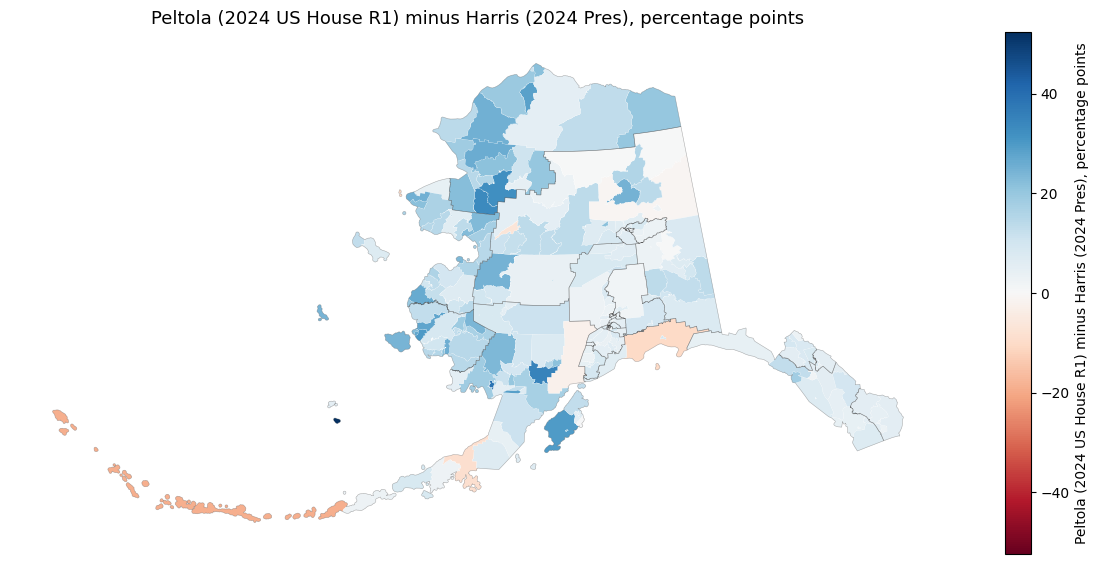

In [5]:
# Project to Alaska Albers (EPSG:3338) so Aleutians don't crash into the
# antimeridian and squish Alaska into a sliver. The raw shapefile is WGS84.
gdf_ak = gdf.to_crs("EPSG:3338")

def render_map(gdf, column, title, cmap, *, diverging=False, outfile):
    precincts = gdf[gdf["row_type"] == "precinct"]
    hd_abs = gdf[gdf["row_type"] == "hd_absentee"]

    fig, ax = plt.subplots(figsize=(12, 9))
    kwargs = dict(
        column=column, ax=ax, cmap=cmap,
        edgecolor="white", linewidth=0.1,
        legend=True, legend_kwds={"label": title, "shrink": 0.6},
        missing_kwds={"color": "lightgrey"},
    )
    if diverging:
        bound = max(abs(gdf[column].min()), abs(gdf[column].max()))
        kwargs.update(vmin=-bound, vmax=bound)
    precincts.plot(**kwargs)
    hd_abs.boundary.plot(ax=ax, edgecolor="black", linewidth=0.4, alpha=0.3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=13, pad=12)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

render_map(
    gdf_ak, "overperformance_pp",
    "Peltola (2024 US House R1) minus Harris (2024 Pres), percentage points",
    cmap="RdBu", diverging=True,
    outfile=MAPS / "overperformance_pp.png",
)

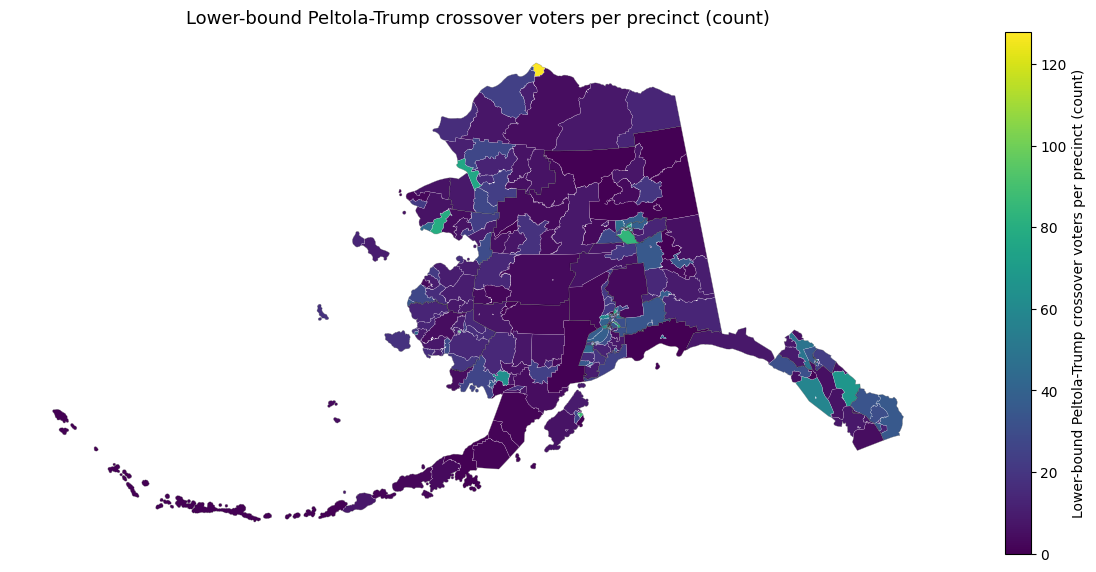

In [6]:
render_map(
    gdf_ak, "splitticket_lb",
    "Lower-bound Peltola-Trump crossover voters per precinct (count)",
    cmap="viridis", diverging=False,
    outfile=MAPS / "splitticket_density.png",
)

## 5. Top-N tables

Top 25 units by each metric, saved as CSV under `outputs/tables/`.

In [7]:
tables = {
    "top25_overperformance_pp_precincts.csv":
        metrics.top_n(gdf, "overperformance_pp", n=25, row_type="precinct"),
    "top25_splitticket_lb_precincts.csv":
        metrics.top_n(gdf, "splitticket_lb", n=25, row_type="precinct"),
    "top25_overperformance_pp_hd_absentee.csv":
        metrics.top_n(gdf, "overperformance_pp", n=25, row_type="hd_absentee"),
    "top25_splitticket_lb_hd_absentee.csv":
        metrics.top_n(gdf, "splitticket_lb", n=25, row_type="hd_absentee"),
}
for name, df in tables.items():
    df.to_csv(TABLES / name, index=False, float_format="%.3f")
    print(f"wrote {name} ({len(df)} rows)")

tables["top25_overperformance_pp_precincts.csv"].head(10)

wrote top25_overperformance_pp_precincts.csv (25 rows)
wrote top25_splitticket_lb_precincts.csv (25 rows)
wrote top25_overperformance_pp_hd_absentee.csv (25 rows)
wrote top25_splitticket_lb_hd_absentee.csv (25 rows)


,row_type,precinct_name,house_district,peltola_votes,harris_votes,peltola_pct_r1,harris_pct,overperformance_pp,splitticket_lb
0,precinct,37-750 St. George Island,37,6,2,85.714286,33.333333,52.380952,4
1,precinct,37-732 Manokotak,37,62,24,62.000000,23.529412,38.470588,38
2,precinct,37-728 Lake Iliamna No. 2,37,47,23,66.197183,31.081081,35.116102,24
3,precinct,40-012 Buckland,40,57,30,70.370370,37.037037,33.333333,27
4,precinct,40-036 Selawik,40,42,19,56.756757,24.675325,32.081432,23
5,precinct,38-844 Nightmute,38,20,11,66.666667,36.666667,30.000000,9
6,precinct,05-815 Kodiak Island South,5,13,7,76.470588,46.666667,29.803922,6
7,precinct,37-748 South Naknek,37,11,6,68.750000,40.000000,28.750000,5
8,precinct,40-006 Atqasuk,40,17,7,48.571429,20.000000,28.571429,10
9,precinct,38-842 Newtok,38,34,21,68.000000,40.384615,27.615385,13


In [8]:
tables["top25_splitticket_lb_precincts.csv"].head(10)

,row_type,precinct_name,house_district,peltola_votes,harris_votes,peltola_pct_r1,harris_pct,overperformance_pp,splitticket_lb
0,precinct,40-010 Browerville,40,406,278,65.483871,43.437500,22.046371,128
1,precinct,35-596 University West,35,681,584,53.161593,45.625000,7.536593,97
2,precinct,38-810 Bethel No. 2,38,367,275,64.499121,48.586572,15.912549,92
3,precinct,20-670 University No. 5,20,725,637,56.596409,49.151235,7.445174,88
4,precinct,05-830 Mission Road,5,577,490,41.781318,34.950071,6.831247,87
5,precinct,35-582 Chena,35,703,619,49.928977,43.560873,6.368105,84
6,precinct,16-460 West Anchorage No. 3,16,628,546,60.442733,52.298851,8.143883,82
7,precinct,23-805 Chugach Park No. 1,23,456,375,43.469971,35.344015,8.125956,81
8,precinct,32-385 Badger No. 2,32,346,266,29.879102,22.676897,7.202205,80
9,precinct,39-926 Nome No. 2,39,366,287,64.210526,49.740035,14.470492,79


## 6. Interactive folium map

Two toggleable layers (overperformance_pp, splitticket_lb), tooltips on every
polygon, saved to `docs/index.html` for GitHub Pages.

In [9]:
import branca.colormap as cm
import folium

# Project to WGS84 for folium. Simplify in a planar CRS (EPSG:3338, Alaska
# Albers, meters) so the tolerance is meaningful; 200 m is fine at web zoom
# levels and cuts the HTML from ~55 MB to ~3 MB.
wgs = gdf.to_crs("EPSG:3338")
wgs["geometry"] = wgs.geometry.simplify(200, preserve_topology=True)
wgs = wgs.to_crs("EPSG:4326")
wgs = wgs[~wgs.geometry.is_empty & wgs.geometry.notna()].copy()

# Pre-round floats for cleaner tooltip display.
for col in ["peltola_pct_r1", "harris_pct", "trump_pct", "overperformance_pp"]:
    wgs[col] = wgs[col].round(2)

# Center on Alaska.
m = folium.Map(location=[63.0, -152.0], zoom_start=4, tiles="cartodbpositron")

bound_pp = max(abs(wgs["overperformance_pp"].min()),
               abs(wgs["overperformance_pp"].max()))
pp_scale = cm.LinearColormap(
    ["#b2182b", "#f7f7f7", "#2166ac"],
    vmin=-bound_pp, vmax=bound_pp,
    caption="Peltola R1 % − Harris % (percentage points)",
)
lb_max = float(wgs["splitticket_lb"].max())
lb_scale = cm.LinearColormap(
    ["#ffffcc", "#41b6c4", "#253494"],
    vmin=0, vmax=lb_max,
    caption="Peltola-Trump crossover voters (lower bound, count)",
)

def style_fn(metric, scale):
    def _style(feature):
        v = feature["properties"].get(metric)
        return {
            "fillColor": "#bbbbbb" if v is None else scale(v),
            "color": "#000000" if feature["properties"]["row_type"] == "hd_absentee" else "#ffffff",
            "weight": 0.8 if feature["properties"]["row_type"] == "hd_absentee" else 0.3,
            "fillOpacity": 0.55 if feature["properties"]["row_type"] == "hd_absentee" else 0.75,
            "dashArray": "5,3" if feature["properties"]["row_type"] == "hd_absentee" else None,
        }
    return _style

tooltip_fields = [
    "precinct_name", "row_type", "house_district",
    "peltola_votes", "harris_votes",
    "peltola_pct_r1", "harris_pct", "trump_pct",
    "overperformance_pp", "splitticket_lb",
]
tooltip_aliases = [
    "Unit:", "Type:", "House District:",
    "Peltola R1 votes:", "Harris votes:",
    "Peltola R1 %:", "Harris %:", "Trump %:",
    "Peltola − Harris (pp):", "Split-ticket LB:",
]

folium.GeoJson(
    wgs,
    name="Peltola overperformance (pp)",
    style_function=style_fn("overperformance_pp", pp_scale),
    tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, localize=True),
).add_to(m)

folium.GeoJson(
    wgs,
    name="Peltola-Trump crossover (count)",
    style_function=style_fn("splitticket_lb", lb_scale),
    tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, localize=True),
    show=False,
).add_to(m)

pp_scale.add_to(m)
lb_scale.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m.save(str(DOCS / "index.html"))
print(f"wrote {DOCS / 'index.html'} ({(DOCS / 'index.html').stat().st_size // 1024} KB)")
m

wrote /Users/mnksmith/projects/ak-electoral-map/docs/index.html (5411 KB)
